In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('Exam_Score_Prediction.csv')

In [3]:
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [5]:
df.drop(columns='student_id')

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,other,bba,6.50,71.3,yes,5.0,good,self-study,low,easy,86.5
19996,18,male,b.com,3.71,41.6,no,5.9,average,coaching,medium,moderate,60.9
19997,19,other,diploma,7.88,68.2,yes,4.6,poor,group study,low,easy,64.5
19998,19,male,bba,4.60,76.3,no,6.1,good,self-study,medium,moderate,79.0


In [6]:
df.shape

(20000, 13)

In [7]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


Text(0.5, 1.0, 'Exam score distribution')

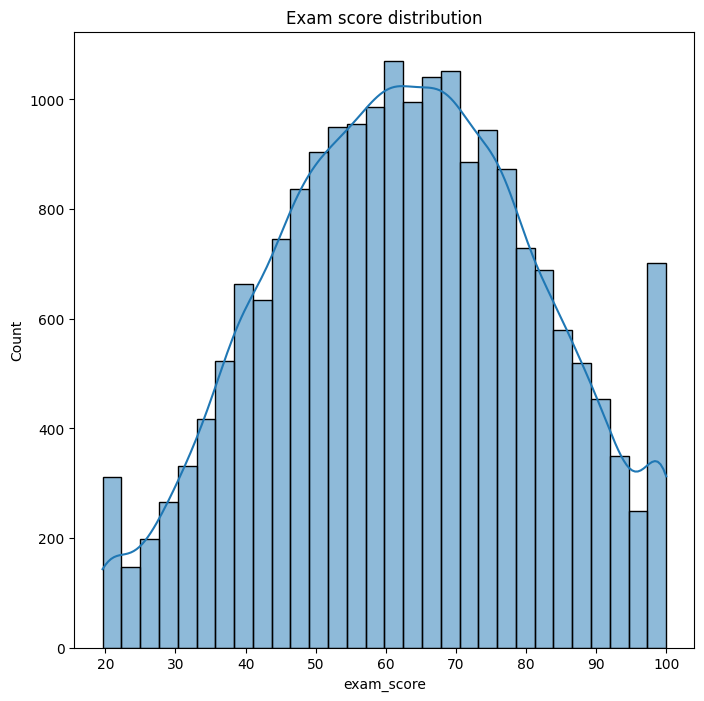

In [12]:
plt.figure(figsize =(8,8))
sns.histplot(df['exam_score'],kde = True,bins = 30)
plt.title('Exam score distribution')

### Scatter Plots for Numerical Features vs. Exam Score

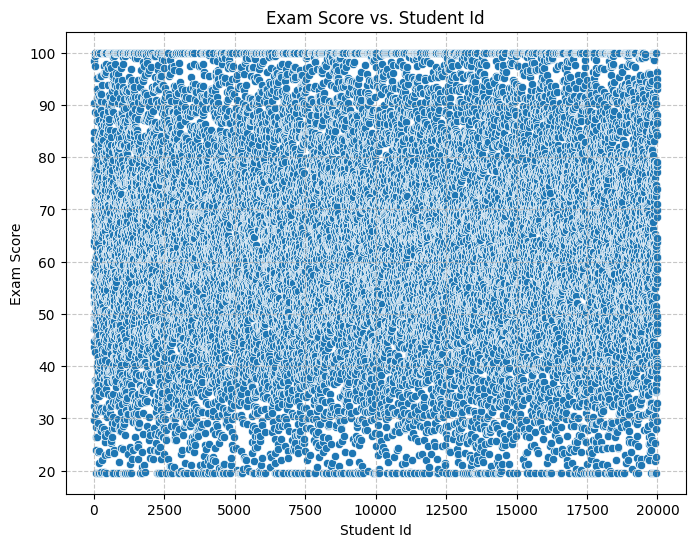

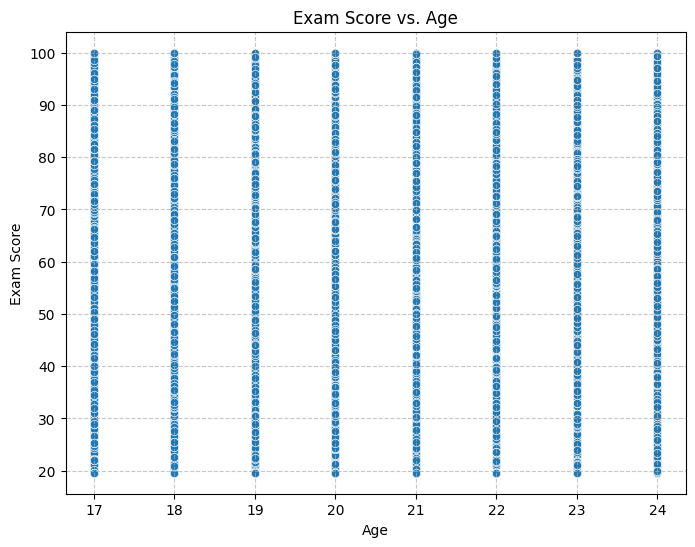

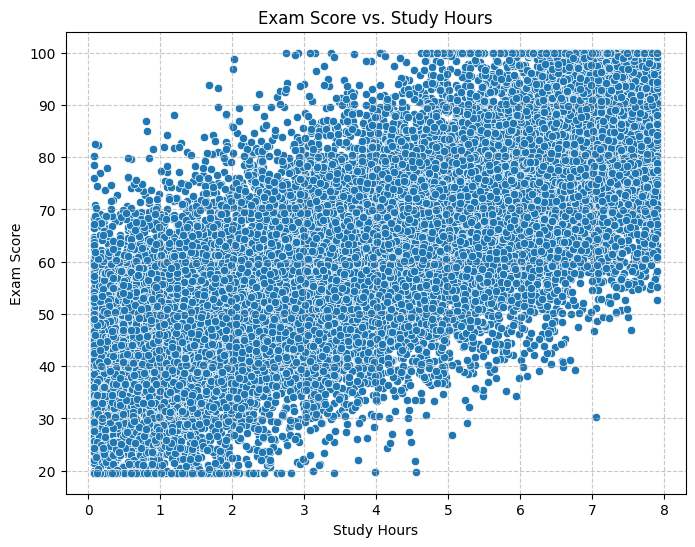

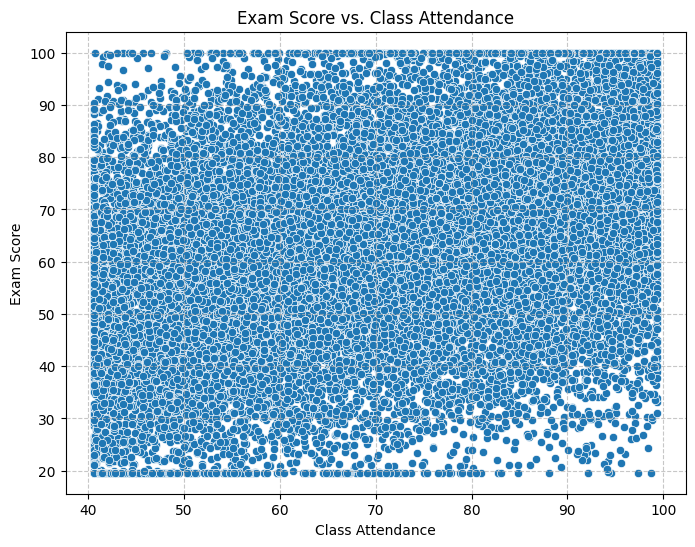

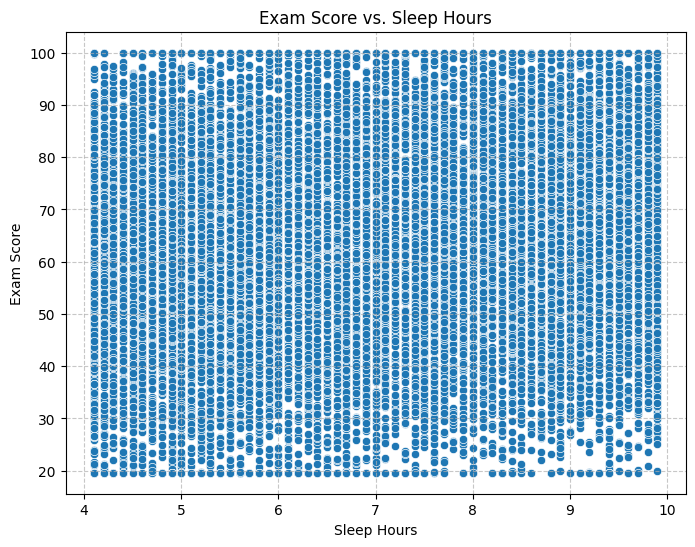

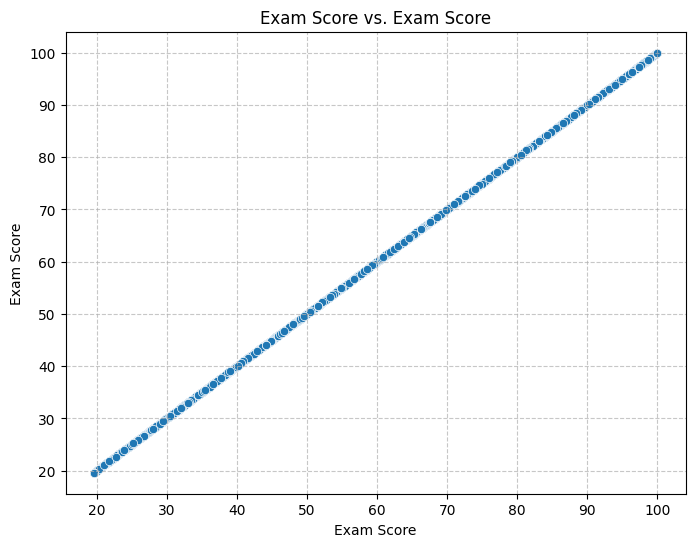

In [14]:
numerical_cols = df.select_dtypes(include = 'number').columns

for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col, y='exam_score', data=df)
    plt.title(f'Exam Score vs. {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Exam Score')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Box Plots for Categorical Features vs. Exam Score

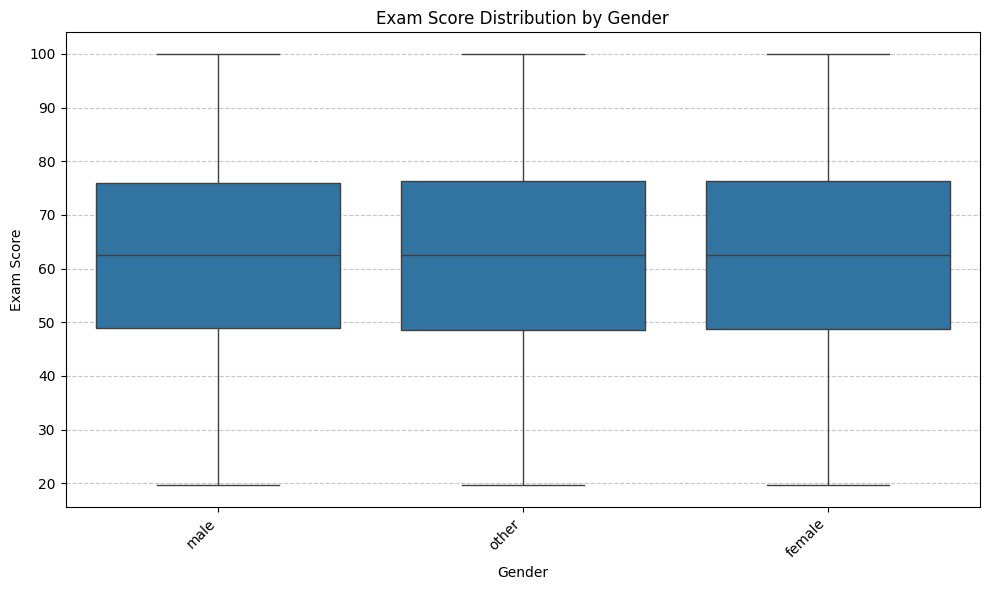

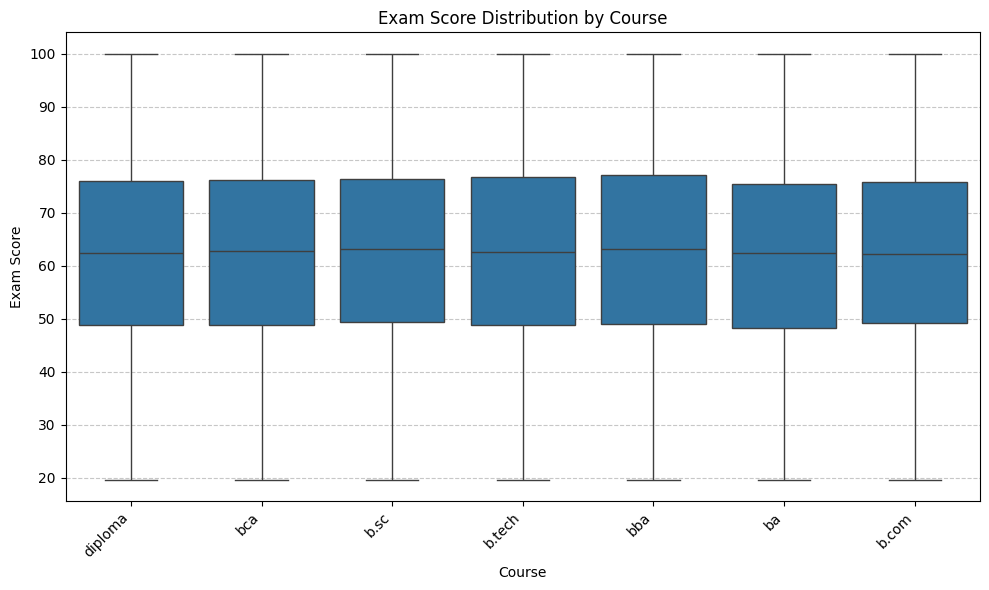

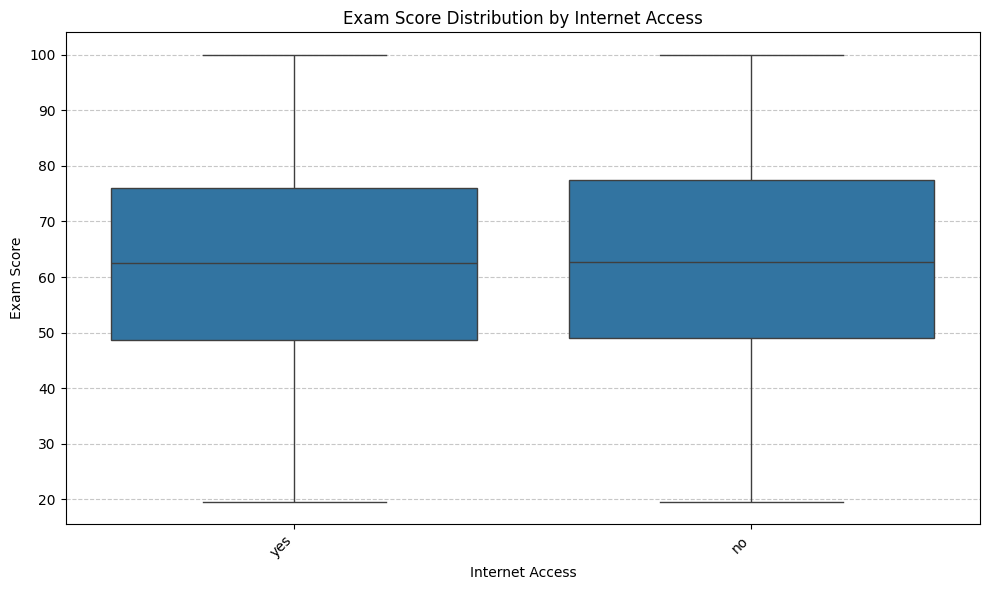

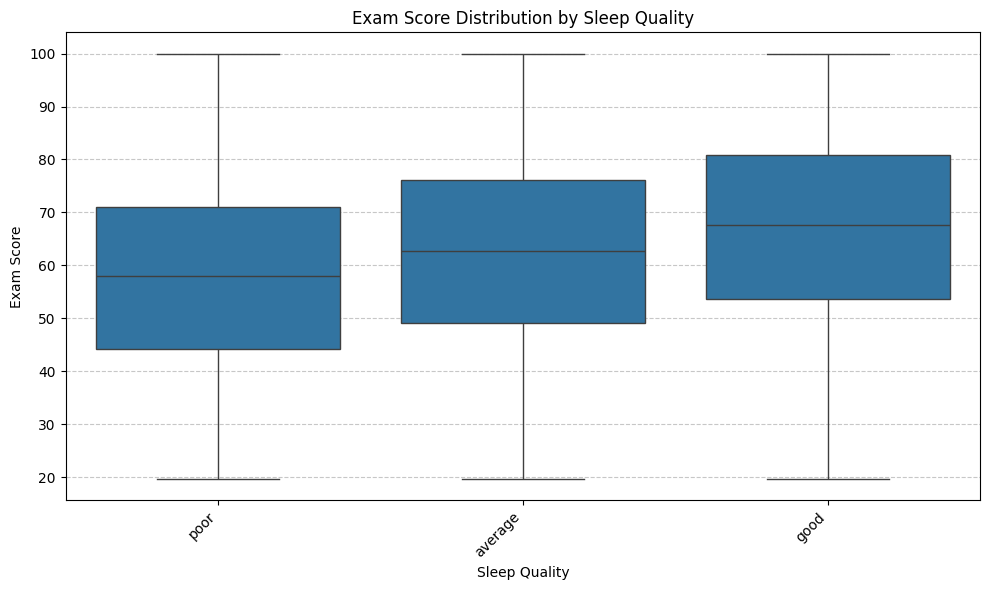

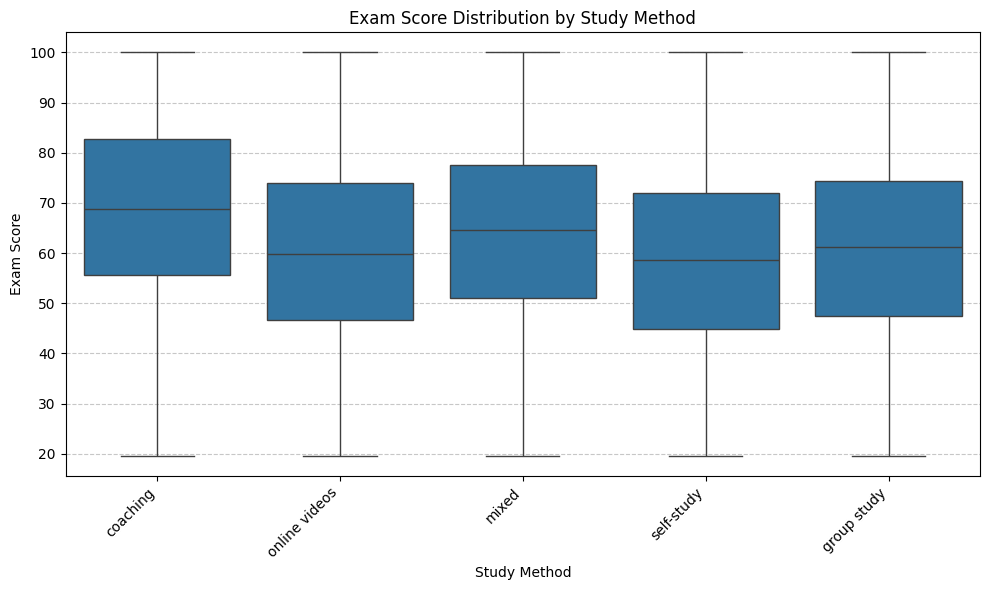

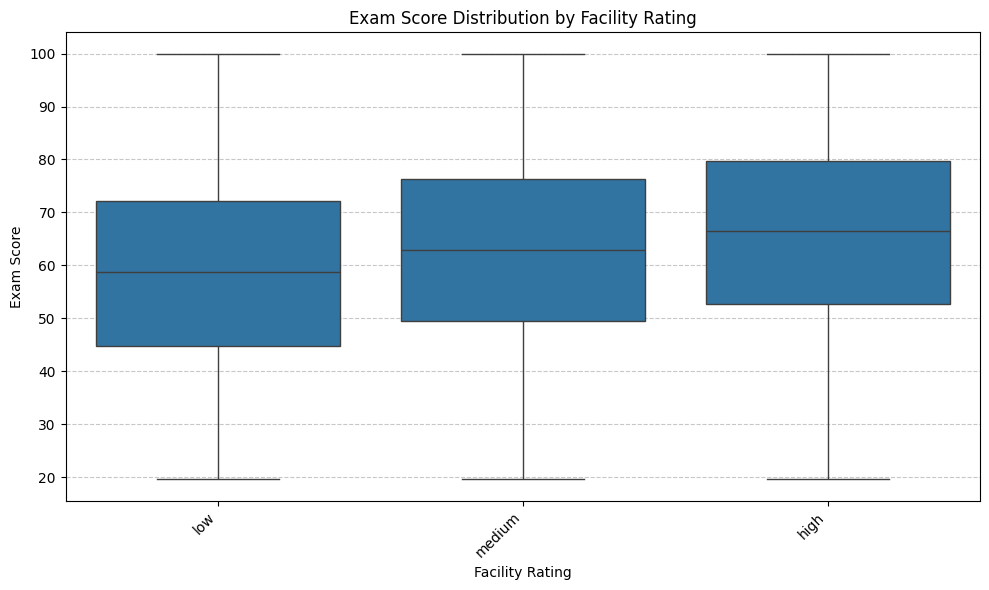

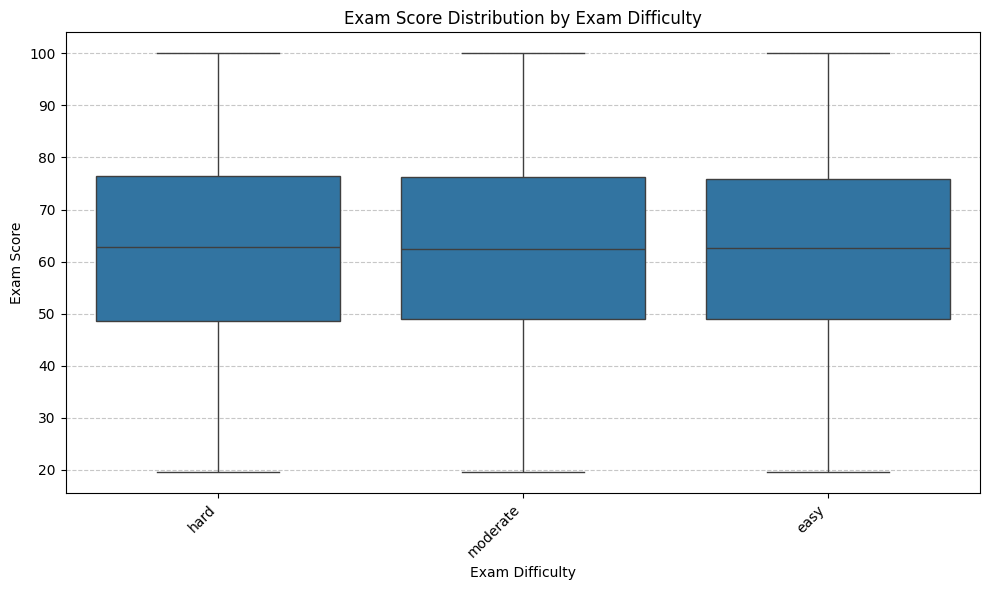

In [15]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='exam_score', data=df)
    plt.title(f'Exam Score Distribution by {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Exam Score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

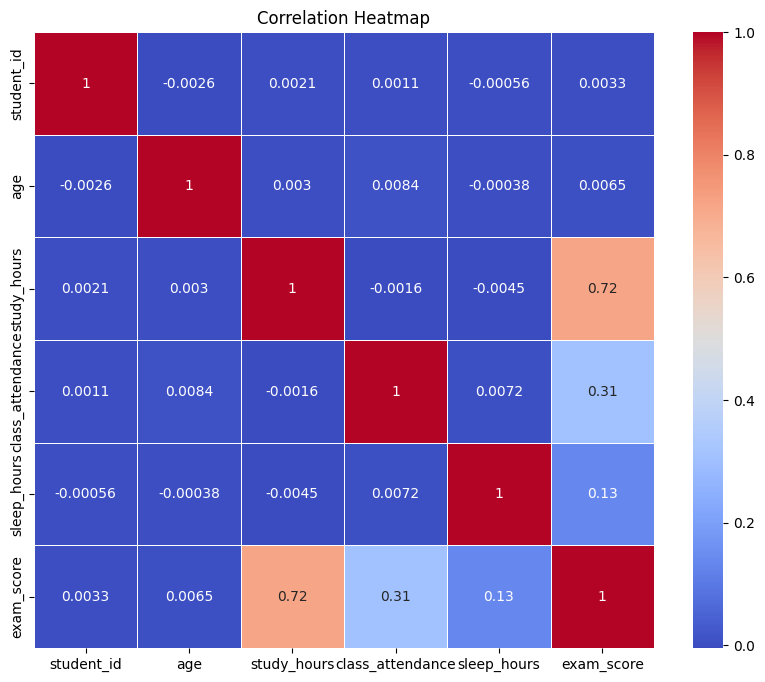

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

### Statistical Testing: Categorical Features vs. Exam Score

In [17]:
from scipy.stats import f_oneway, ttest_ind

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Statistical Test Results (Categorical Features vs. Exam Score):\n")

for col in categorical_cols:
    unique_categories = df[col].nunique()
    if unique_categories > 1:
        print(f"--- {col.replace('_', ' ').title()} ---")
        if unique_categories == 2:
            # Perform independent t-test for two categories
            categories = df[col].unique()
            group1 = df[df[col] == categories[0]]['exam_score']
            group2 = df[df[col] == categories[1]]['exam_score']
            statistic, p_value = ttest_ind(group1, group2, equal_var=False) # Assuming unequal variances
            test_type = 'Independent t-test'
        else:
            # Perform ANOVA for more than two categories
            groups = [df[df[col] == category]['exam_score'] for category in df[col].unique()]
            statistic, p_value = f_oneway(*groups)
            test_type = 'ANOVA'

        print(f"Test Type: {test_type}")
        print(f"Statistic: {statistic:.4f}")
        print(f"P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("Conclusion: There is a statistically significant difference in exam scores across categories.")
        else:
            print("Conclusion: No statistically significant difference in exam scores across categories.")
        print("\n")
    else:
        print(f"--- {col.replace('_', ' ').title()} ---")
        print(f"Skipping statistical test for '{col}' as it has only one unique category.")
        print("\n")

Statistical Test Results (Categorical Features vs. Exam Score):

--- Gender ---
Test Type: ANOVA
Statistic: 0.1906
P-value: 0.8265
Conclusion: No statistically significant difference in exam scores across categories.


--- Course ---
Test Type: ANOVA
Statistic: 0.6144
P-value: 0.7190
Conclusion: No statistically significant difference in exam scores across categories.


--- Internet Access ---
Test Type: Independent t-test
Statistic: -1.0930
P-value: 0.2744
Conclusion: No statistically significant difference in exam scores across categories.


--- Sleep Quality ---
Test Type: ANOVA
Statistic: 411.7933
P-value: 0.0000
Conclusion: There is a statistically significant difference in exam scores across categories.


--- Study Method ---
Test Type: ANOVA
Statistic: 180.5267
P-value: 0.0000
Conclusion: There is a statistically significant difference in exam scores across categories.


--- Facility Rating ---
Test Type: ANOVA
Statistic: 273.7664
P-value: 0.0000
Conclusion: There is a statistic

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
  df[col] = le.fit_transform(df[col])
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,2,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,3,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,4,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,5,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


In [21]:
X = df.drop(['exam_score','age','gender','internet_access','exam_difficulty','course'], axis=1)
y = df['exam_score']

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [23]:
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)

y_pred = dt_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Decision Tree Regressor Performance:\n")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R-squared Score: {r2}")

Decision Tree Regressor Performance:

Mean Squared Error: 219.70
Mean Absolute Error: 11.82
R-squared Score: 0.39078499407642764


In [24]:
from sklearn.ensemble import AdaBoostRegressor

In [26]:
adaboost_regressor  = AdaBoostRegressor(random_state=42)
adaboost_regressor.fit(X_train, y_train)

y_pred_ada = adaboost_regressor.predict(X_test)
mse_ada = mean_squared_error(y_test, y_pred_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

print(f"AdaBoost Regressor Performance:\n")
print(f"Mean Squared Error: {mse_ada:.2f}")
print(f"Mean Absolute Error: {mae_ada:.2f}")
print(f"R-squared Score: {r2_ada}")

AdaBoost Regressor Performance:

Mean Squared Error: 117.74
Mean Absolute Error: 8.87
R-squared Score: 0.6735282270557047


In [28]:
from xgboost import XGBRegressor
xgb_regressor = XGBRegressor(random_state=42)
xgb_regressor.fit(X_train, y_train)
y_pred_xgb = xgb_regressor.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Performance:\n")
print(f"Mean Squared Error: {mse_xgb:.2f}")
print(f"Mean Absolute Error: {mae_xgb:.2f}")
print(f"R-squared Score: {r2_xgb}")


XGBoost Regressor Performance:

Mean Squared Error: 109.97
Mean Absolute Error: 8.44
R-squared Score: 0.6950673472118135


now doing hyper parameter tuning

In [29]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2]
}

# Initialize XGBRegressor
xgb = XGBRegressor(random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R-squared score found: ", grid_search.best_score_)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits
Best parameters found:  {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}
Best R-squared score found:  0.7229976267199345


In [30]:
best_params = grid_search.best_params_

# Initialize XGBRegressor with best parameters
xgb_tuned = XGBRegressor(**best_params, random_state=42)

# Train the tuned model
xgb_tuned.fit(X_train, y_train)

# Make predictions on the test set
y_pred_tuned_xgb = xgb_tuned.predict(X_test)

# Evaluate the tuned model's performance
mse_tuned_xgb = mean_squared_error(y_test, y_pred_tuned_xgb)
mae_tuned_xgb = mean_absolute_error(y_test, y_pred_tuned_xgb)
r2_tuned_xgb = r2_score(y_test, y_pred_tuned_xgb)

print(f"Tuned XGBoost Regressor Performance:\n")
print(f"Mean Squared Error: {mse_tuned_xgb:.2f}")
print(f"Mean Absolute Error: {mae_tuned_xgb:.2f}")
print(f"R-squared Score: {r2_tuned_xgb:.4f}")

Tuned XGBoost Regressor Performance:

Mean Squared Error: 97.42
Mean Absolute Error: 7.96
R-squared Score: 0.7299


In [31]:
import pickle
with open('label_encoders.pkl','wb') as f:
  pickle.dump(le,f)
print("label encoder saved to pickle file ")
with open('xgb_tuned_model.pkl','wb') as f:
  pickle.dump(xgb_tuned,f)
print("xgb_tuned saved to pickle file ")

label encoder saved to pickle file 
xgb_tuned saved to pickle file 


### Streamlit Application for Exam Score Prediction

To run this Streamlit application, you will need to:
1.  **Install Streamlit:** `pip install streamlit`
2.  **Save the code below** into a Python file (e.g., `app.py`).
3.  **Run the application** from your terminal using: `streamlit run app.py`

In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder

# Load the tuned XGBoost model
with open('xgb_tuned_model.pkl', 'rb') as f:
    xgb_tuned = pickle.load(f)



# Define the mappings for the categorical features used in the model (X)
categorical_mappings = {
    'sleep_quality': {'average': 0, 'good': 1, 'poor': 2},
    'study_method': {'coaching': 0, 'no study': 1, 'group study': 2, 'online videos': 3, 'self-study': 4},
    'facility_rating': {'high': 0, 'low': 1, 'medium': 2}
}

# Streamlit App Title
st.title('Exam Score Prediction Model')
st.write('Enter the student details to predict their exam score.')

# Input features
st.sidebar.header('Student Features')

def user_input_features():
    student_id = st.sidebar.number_input('Student ID', min_value=1, value=1)
    study_hours = st.sidebar.slider('Study Hours', min_value=0.0, max_value=10.0, value=5.0, step=0.1)
    class_attendance = st.sidebar.slider('Class Attendance (%)', min_value=0.0, max_value=100.0, value=75.0, step=0.1)
    sleep_hours = st.sidebar.slider('Sleep Hours', min_value=0.0, max_value=12.0, value=7.0, step=0.1)

    # Categorical features with their mappings
    sleep_quality_str = st.sidebar.selectbox('Sleep Quality', options=list(categorical_mappings['sleep_quality'].keys()))
    study_method_str = st.sidebar.selectbox('Study Method', options=list(categorical_mappings['study_method'].keys()))
    facility_rating_str = st.sidebar.selectbox('Facility Rating', options=list(categorical_mappings['facility_rating'].keys()))

    # Encode categorical features
    sleep_quality = categorical_mappings['sleep_quality'][sleep_quality_str]
    study_method = categorical_mappings['study_method'][study_method_str]
    facility_rating = categorical_mappings['facility_rating'][facility_rating_str]

    data = {
        'student_id': student_id,
        'study_hours': study_hours,
        'class_attendance': class_attendance,
        'sleep_hours': sleep_hours,
        'sleep_quality': sleep_quality,
        'study_method': study_method,
        'facility_rating': facility_rating
    }
    features = pd.DataFrame(data, index=[0])
    return features

input_df = user_input_features()

st.subheader('User Input Features')
st.write(input_df)

# Predict button
if st.button('Predict Exam Score'):
    prediction = xgb_tuned.predict(input_df)
    st.subheader('Predicted Exam Score')
    st.write(f'The predicted exam score is: **{prediction[0]:.2f}**')

